# Modelado Agroclimático del Rendimiento de Soja (1980–2024)

## Análisis Estadístico, Machine Learning y Simulación Climática

Este notebook desarrolla el modelado agroclimático del rendimiento de soja utilizando variables climáticas históricas NOAA, variables de suelo y técnicas de análisis estadístico y machine learning.

Se implementan modelos OLS y Random Forest, análisis de correlación, validación temporal y simulación de escenarios climáticos con el objetivo de evaluar la relación entre variables agroclimáticas y productividad agrícola.

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
dataset = pd.read_csv(
    "../Procesados/dataset_agroclimatico_base.csv"
)

dataset.head()

,Cultivo,Campaña,Provincia,Departamento,idProvincia,idDepartamento,Rendimiento,temp_media_prom,temp_max_extrema,temp_min_extrema,precipitacion_total,viento_prom,presion_prom,dias_lluvia,depto_key,score_suelo_promedio
0,Soja total,1980/81,SANTA FE,CASEROS,82,14,2156,17.415370,39.00,-4.00,1241.298,14.431151,1014.972055,111,CASEROS,2.516667
1,Soja total,1981/82,SANTA FE,CASEROS,82,14,2500,18.083746,38.00,-1.22,534.924,14.739758,1014.103374,73,CASEROS,2.516667
2,Soja total,1982/83,SANTA FE,CASEROS,82,14,1386,16.964637,38.22,-4.72,663.956,18.233045,1013.934366,82,CASEROS,2.516667
3,Soja total,1983/84,SANTA FE,CASEROS,82,14,2574,17.223060,38.61,-4.89,1160.780,14.358005,1014.048493,104,CASEROS,2.516667
4,Soja total,1987/88,SANTA FE,CASEROS,82,14,2438,16.424200,36.00,-6.50,815.848,14.545086,1015.061714,60,CASEROS,2.516667


In [3]:
X = dataset[
    [
        "score_suelo_promedio",
        "temp_media_prom",
        "temp_max_extrema",
        "temp_min_extrema",
        "precipitacion_total",
        "viento_prom",
        "presion_prom",
        "dias_lluvia"
    ]
]

y = dataset["Rendimiento"]

In [4]:
X_ols = sm.add_constant(X)

In [5]:
modelo_ols = sm.OLS(
    y,
    X_ols
).fit()

In [6]:
from sklearn.model_selection import train_test_split

X_train = X.iloc[:-5]
X_test = X.iloc[-5:]

y_train = y.iloc[:-5]
y_test = y.iloc[-5:]

In [7]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

In [8]:
modelo_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
y_pred = modelo_lr.predict(X_test)

In [10]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("R²:", round(r2, 3))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

R²: 0.314
MAE: 541.84
RMSE: 671.36


In [11]:
resultado = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred
})

resultado

,Real,Predicho
0,2698,2858.902043
1,2859,2855.286266
2,2022,2655.076622
3,1377,2335.630310
4,3781,2828.142666


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [14]:
import statsmodels.api as sm

In [15]:
X = dataset[
    [
        "score_suelo_promedio",
        "temp_media_prom",
        "temp_max_extrema",
        "temp_min_extrema",
        "precipitacion_total",
        "viento_prom",
        "presion_prom",
        "dias_lluvia"
    ]
]

y = dataset["Rendimiento"]

In [16]:
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

In [17]:
df_modelo = pd.concat([X, y], axis=1).dropna()

X = df_modelo.drop(columns="Rendimiento")
y = df_modelo["Rendimiento"]

In [18]:
X_ols = sm.add_constant(X)

In [19]:
modelo_ols = sm.OLS(y, X_ols).fit()

In [20]:
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     26.36
Date:                Thu, 28 May 2026   Prob (F-statistic):           8.88e-29
Time:                        13:43:58   Log-Likelihood:                -1829.4
No. Observations:                 240   AIC:                             3677.
Df Residuals:                     231   BIC:                             3708.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 3.624e+04 

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [22]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif

,Variable,VIF
0,score_suelo_promedio,50.955554
1,temp_media_prom,1395.607473
2,temp_max_extrema,960.739481
3,temp_min_extrema,11.647276
4,precipitacion_total,21.780074
5,viento_prom,80.673121
6,presion_prom,2102.569641
7,dias_lluvia,60.285456


In [23]:
X = dataset[
    [
        "score_suelo_promedio",
        "temp_max_extrema",
        "temp_min_extrema",
        "precipitacion_total",
        "viento_prom",
        "dias_lluvia"
    ]
]

In [24]:
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

df_modelo = pd.concat([X, y], axis=1).dropna()

X = df_modelo.drop(columns="Rendimiento")
y = df_modelo["Rendimiento"]

X_ols = sm.add_constant(X)

modelo_ols = sm.OLS(y, X_ols).fit()

print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.461
Method:                 Least Squares   F-statistic:                     35.13
Date:                Thu, 28 May 2026   Prob (F-statistic):           4.03e-30
Time:                        13:48:28   Log-Likelihood:                -1829.9
No. Observations:                 240   AIC:                             3674.
Df Residuals:                     233   BIC:                             3698.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 7086.5664 

In [25]:
from sklearn.ensemble import RandomForestRegressor

In [26]:
X = dataset[
    [
        "score_suelo_promedio",
        "temp_max_extrema",
        "temp_min_extrema",
        "precipitacion_total",
        "viento_prom",
        "dias_lluvia"
    ]
]

y = dataset["Rendimiento"]

In [27]:
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

df_modelo = pd.concat([X, y], axis=1).dropna()

X = df_modelo.drop(columns="Rendimiento")
y = df_modelo["Rendimiento"]

In [28]:
X_train = X.iloc[:-5]
X_test = X.iloc[-5:]

y_train = y.iloc[:-5]
y_test = y.iloc[-5:]

In [29]:
modelo_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

In [30]:
modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [31]:
y_pred_rf = modelo_rf.predict(X_test)

In [32]:
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

print("R²:", round(r2_rf, 3))
print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))

R²: 0.892
MAE: 231.36
RMSE: 266.98


In [33]:
resultado_rf = pd.DataFrame({
    "Real": y_test.values,
    "Predicho_RF": y_pred_rf
})

resultado_rf

,Real,Predicho_RF
0,2698,2954.253333
1,2859,2770.470000
2,2022,2493.073333
3,1377,1509.706667
4,3781,3572.763333


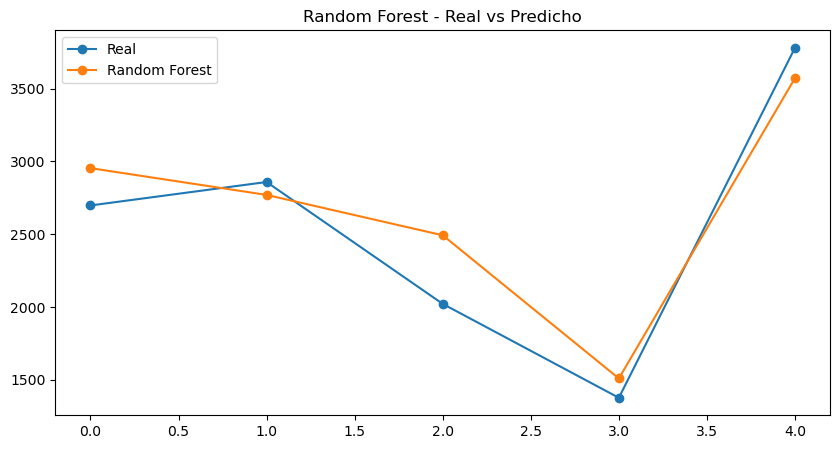

In [34]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    marker="o",
    label="Real"
)

plt.plot(
    y_pred_rf,
    marker="o",
    label="Random Forest"
)

plt.title("Random Forest - Real vs Predicho")

plt.legend()

plt.show()

In [35]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias

,Variable,Importancia
3,precipitacion_total,0.320924
4,viento_prom,0.310891
5,dias_lluvia,0.106578
2,temp_min_extrema,0.099909
1,temp_max_extrema,0.085605
0,score_suelo_promedio,0.076093


# Modelado Agroclimático del Rendimiento de Soja

## Construcción del dataset

Se construyó un dataset agroclimático integrando variables climáticas históricas obtenidas desde NOAA GSOD (1980–2024), datos de rendimiento de soja y variables de suelo.

Durante el proceso se realizaron tareas de auditoría y limpieza de datos:

* revisión de campañas problemáticas,
* corrección de inconsistencias detectadas en 2015 y 2016,
* eliminación de campañas con datos incompletos o inconsistentes,
* reconstrucción del dataset final limpio `dataset_agroclimatico_base.csv`.

El dataset final integró variables climáticas y agronómicas relevantes para el análisis del rendimiento.

---

# Variables utilizadas

Las variables predictoras utilizadas en los modelos fueron:

* score_suelo_promedio
* temp_max_extrema
* temp_min_extrema
* precipitacion_total
* viento_prom
* dias_lluvia

La variable objetivo fue:

* Rendimiento de soja

---

# Modelo OLS (Ordinary Least Squares)

Se implementó inicialmente un modelo de regresión lineal múltiple OLS con el objetivo de interpretar estadísticamente el efecto de las variables climáticas sobre el rendimiento de soja.

El modelo obtuvo:

* R² ≈ 0.475
* Adj. R² ≈ 0.461

Esto indica que aproximadamente el 47.5% de la variabilidad del rendimiento puede ser explicada por las variables climáticas y de suelo incluidas en el modelo.

El test global del modelo resultó altamente significativo:

* Prob(F-statistic) ≈ 4.03e-30

lo cual confirma la existencia de relación estadística entre las variables predictoras y el rendimiento.

---

# Variables significativas en OLS

Las variables con significancia estadística (p < 0.05) fueron:

## Temperaturas extremas

Las temperaturas máximas y mínimas extremas mostraron coeficientes negativos y significativos, indicando que eventos térmicos extremos afectan negativamente el rendimiento de soja.

## Precipitación total

La precipitación total presentó un efecto positivo significativo sobre el rendimiento, lo cual es consistente con el rol fundamental de la disponibilidad hídrica en el desarrollo del cultivo.

## Viento promedio

El viento promedio mostró un efecto negativo importante sobre el rendimiento, posiblemente asociado a procesos de evapotranspiración, estrés hídrico y pérdida de humedad disponible.

## Días de lluvia

La frecuencia de días con lluvia presentó un efecto positivo significativo, sugiriendo que no sólo importa el volumen total de precipitación sino también su distribución temporal.

---

# Multicolinealidad

Se detectó multicolinealidad elevada entre algunas variables climáticas mediante el cálculo del Variance Inflation Factor (VIF), particularmente entre variables térmicas y de presión atmosférica.

Por este motivo se realizó una depuración del modelo eliminando variables redundantes para mejorar la estabilidad estadística e interpretación del modelo.

Luego de esta depuración:

* el modelo mantuvo prácticamente el mismo poder explicativo,
* disminuyó considerablemente el nivel de colinealidad,
* mejoró la estabilidad de los coeficientes.

---

# Modelo Random Forest

Posteriormente se implementó un modelo Random Forest Regressor utilizando validación temporal, reservando las últimas campañas para evaluación del modelo.

El modelo Random Forest obtuvo:

* R² ≈ 0.892
* MAE ≈ 231
* RMSE ≈ 267

Estos resultados muestran un incremento muy importante en la capacidad predictiva respecto al modelo OLS.

El modelo logró reproducir adecuadamente tanto campañas de alto rendimiento como campañas de bajo rendimiento, mostrando buena capacidad para capturar relaciones no lineales entre variables climáticas y rendimiento agrícola.

---

# Importancia de variables

El análisis de importancia de variables indicó que los factores más relevantes para el rendimiento fueron:

1. precipitacion_total
2. viento_prom
3. dias_lluvia

Las variables térmicas también presentaron influencia relevante, aunque menor en comparación con las variables asociadas al componente hídrico.

Estos resultados sugieren que, para las campañas analizadas, la disponibilidad y dinámica hídrica constituyen los principales factores explicativos del rendimiento de soja.

---

# Conclusiones preliminares

Los resultados obtenidos muestran que:

* las variables agroclimáticas poseen una relación significativa con el rendimiento de soja,
* los modelos no lineales como Random Forest presentan una capacidad predictiva considerablemente superior al modelo lineal OLS,
* las variables asociadas al agua (precipitación, frecuencia de lluvia y viento) aparecen como factores dominantes en la explicación del rendimiento,
* el proyecto constituye una base sólida para futuras etapas de modelado agroclimático avanzado.

Como líneas futuras de trabajo se plantea incorporar nuevas variables como:

* humedad relativa,
* índices de sequía,
* ENSO,
* olas de calor,
* variables fenológicas,
* y modelos avanzados de machine learning.


In [36]:
import seaborn as sns

In [37]:
corr = dataset[
    [
        "score_suelo_promedio",
        "temp_max_extrema",
        "temp_min_extrema",
        "precipitacion_total",
        "viento_prom",
        "dias_lluvia",
        "Rendimiento"
    ]
].corr()

corr

,score_suelo_promedio,temp_max_extrema,temp_min_extrema,precipitacion_total,viento_prom,dias_lluvia,Rendimiento
score_suelo_promedio,1.000000e+00,6.358056e-16,-2.506929e-16,-1.032573e-16,-8.302079e-17,-1.559313e-16,-0.058651
temp_max_extrema,6.358056e-16,1.000000e+00,-4.976199e-02,-3.400084e-01,-2.484956e-01,-8.980888e-02,-0.134720
temp_min_extrema,-2.506929e-16,-4.976199e-02,1.000000e+00,1.124514e-01,3.142238e-02,4.031788e-01,-0.049944
precipitacion_total,-1.032573e-16,-3.400084e-01,1.124514e-01,1.000000e+00,-8.071301e-02,5.720214e-01,0.440035
viento_prom,-8.302079e-17,-2.484956e-01,3.142238e-02,-8.071301e-02,1.000000e+00,-3.038996e-01,-0.527715
dias_lluvia,-1.559313e-16,-8.980888e-02,4.031788e-01,5.720214e-01,-3.038996e-01,1.000000e+00,0.413089
Rendimiento,-5.865141e-02,-1.347197e-01,-4.994392e-02,4.400349e-01,-5.277148e-01,4.130886e-01,1.000000


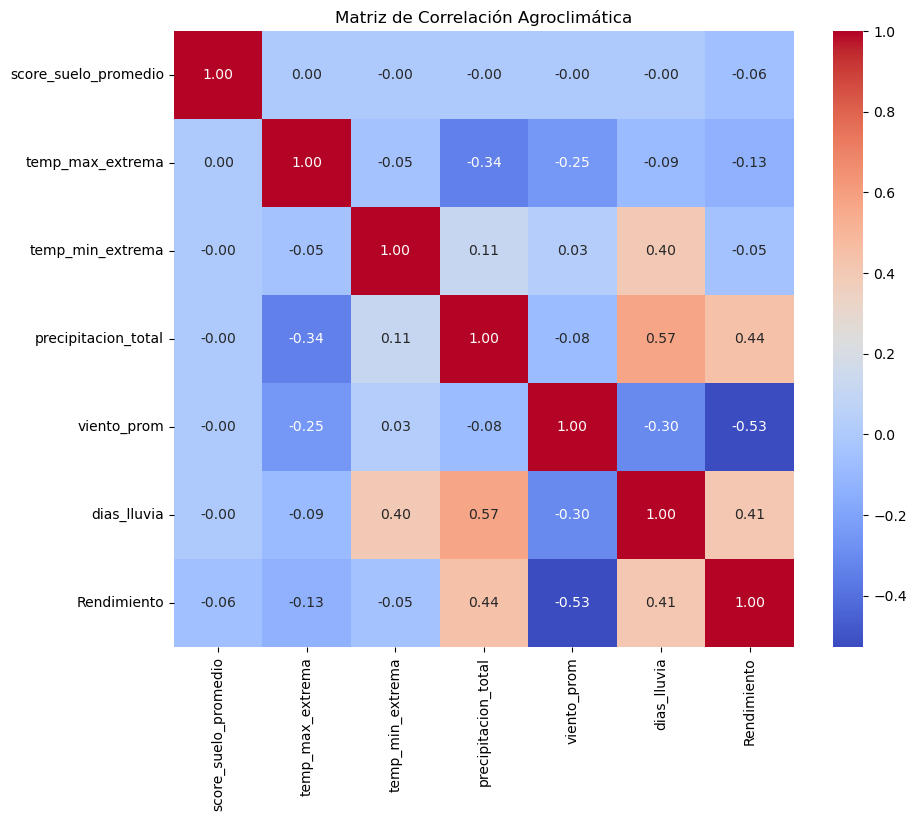

In [38]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación Agroclimática")

plt.show()

In [39]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias

,Variable,Importancia
3,precipitacion_total,0.320924
4,viento_prom,0.310891
5,dias_lluvia,0.106578
2,temp_min_extrema,0.099909
1,temp_max_extrema,0.085605
0,score_suelo_promedio,0.076093


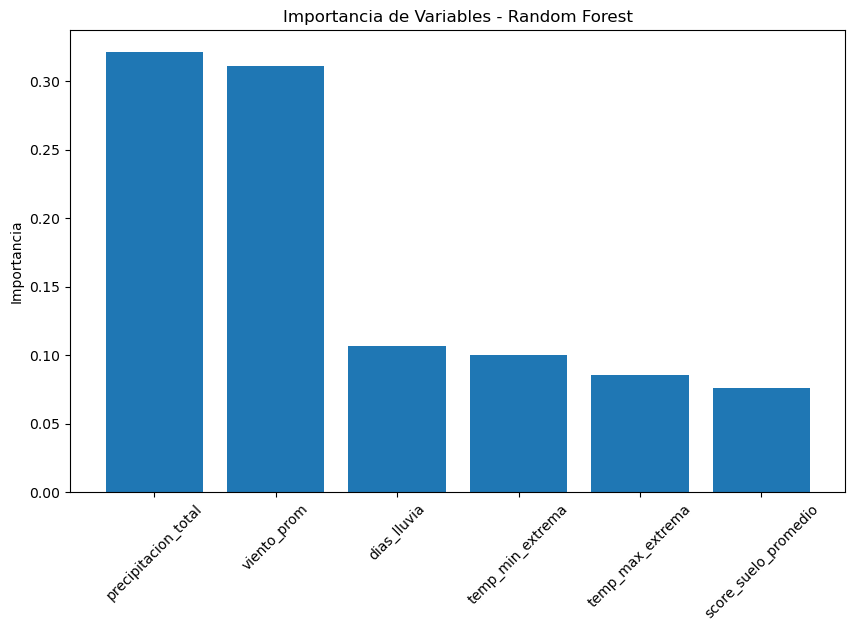

In [40]:
plt.figure(figsize=(10,6))

plt.bar(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.title("Importancia de Variables - Random Forest")

plt.ylabel("Importancia")

plt.xticks(rotation=45)

plt.show()

# Análisis de Correlación e Importancia de Variables

## Matriz de correlación agroclimática

Se construyó una matriz de correlación con el objetivo de analizar las relaciones lineales entre las variables climáticas, de suelo y el rendimiento de soja.

Los resultados muestran que las variables asociadas al componente hídrico presentan las relaciones más importantes con el rendimiento.

### Viento promedio

El viento promedio presentó la correlación negativa más fuerte con el rendimiento:

* correlación ≈ -0.53

Esto sugiere que mayores velocidades de viento podrían asociarse a:

* mayor evapotranspiración,
* pérdida de humedad disponible,
* incremento del estrés hídrico,
* y condiciones menos favorables para el cultivo.

### Precipitación total

La precipitación total mostró una correlación positiva moderada:

* correlación ≈ 0.44

Esto indica que una mayor disponibilidad hídrica se asocia, en general, con mayores rendimientos agrícolas.

### Días de lluvia

Los días de lluvia también presentaron correlación positiva:

* correlación ≈ 0.41

Este resultado sugiere que no sólo importa el volumen total de precipitación, sino también la distribución temporal de las lluvias durante la campaña agrícola.

---

# Importancia de variables en Random Forest

Posteriormente se analizó la importancia de variables utilizando el modelo Random Forest Regressor.

Las variables más importantes fueron:

| Variable             | Importancia |
| -------------------- | ----------- |
| precipitacion_total  | 0.321       |
| viento_prom          | 0.311       |
| dias_lluvia          | 0.107       |
| temp_min_extrema     | 0.100       |
| temp_max_extrema     | 0.086       |
| score_suelo_promedio | 0.076       |

Los resultados refuerzan la hipótesis de que el componente hídrico constituye el principal factor explicativo del rendimiento de soja dentro del dataset analizado.

En particular:

* la precipitación total,
* el viento promedio,
* y la frecuencia de días de lluvia

aparecen como las variables dominantes del modelo predictivo.

---

# Comparación entre OLS y Random Forest

El modelo OLS permitió interpretar estadísticamente las relaciones entre variables climáticas y rendimiento, identificando efectos significativos principalmente asociados a:

* precipitación,
* viento,
* temperaturas extremas,
* y días de lluvia.

Sin embargo, el modelo Random Forest mostró una capacidad predictiva considerablemente superior:

| Modelo        | R² aproximado |
| ------------- | ------------- |
| OLS           | 0.475         |
| Random Forest | 0.892         |

Esto sugiere la existencia de relaciones no lineales e interacciones complejas entre las variables agroclimáticas que son capturadas de manera más eficiente por modelos de machine learning.

---

# Conclusiones preliminares

Los resultados obtenidos hasta el momento indican que:

* las variables climáticas presentan una relación significativa con el rendimiento agrícola,
* el componente hídrico parece ser el principal factor explicativo del rendimiento de soja,
* los modelos de machine learning permiten capturar patrones complejos que no son completamente representados mediante modelos lineales tradicionales,
* y el enfoque agroclimático implementado constituye una base sólida para futuras etapas de modelado predictivo avanzado.


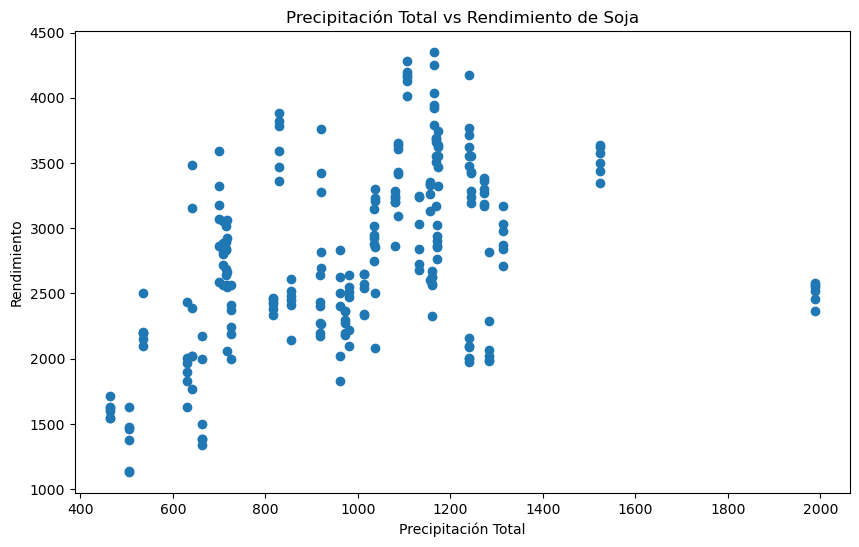

In [41]:
plt.figure(figsize=(10,6))

plt.scatter(
    dataset["precipitacion_total"],
    dataset["Rendimiento"]
)

plt.xlabel("Precipitación Total")

plt.ylabel("Rendimiento")

plt.title("Precipitación Total vs Rendimiento de Soja")

plt.show()

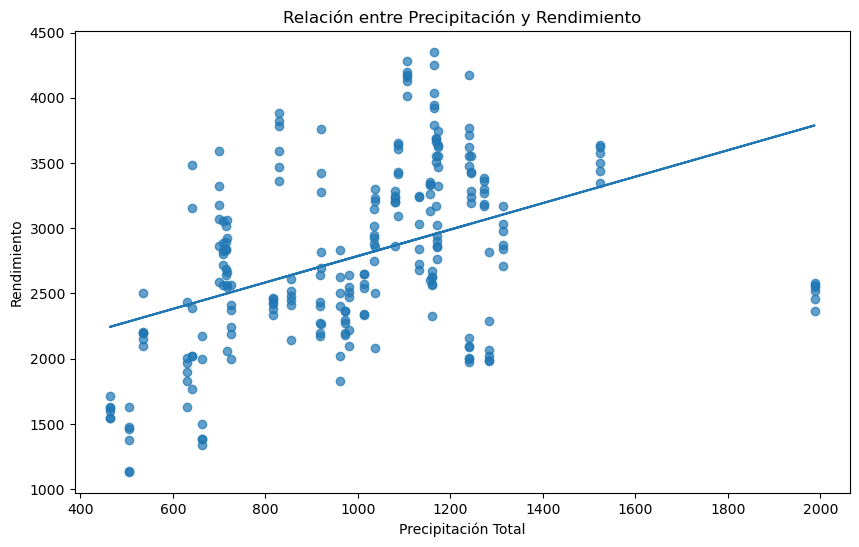

In [42]:
plt.figure(figsize=(10,6))

plt.scatter(
    dataset["precipitacion_total"],
    dataset["Rendimiento"],
    alpha=0.7
)

z = np.polyfit(
    dataset["precipitacion_total"],
    dataset["Rendimiento"],
    1
)

p = np.poly1d(z)

plt.plot(
    dataset["precipitacion_total"],
    p(dataset["precipitacion_total"])
)

plt.xlabel("Precipitación Total")

plt.ylabel("Rendimiento")

plt.title("Relación entre Precipitación y Rendimiento")

plt.show()

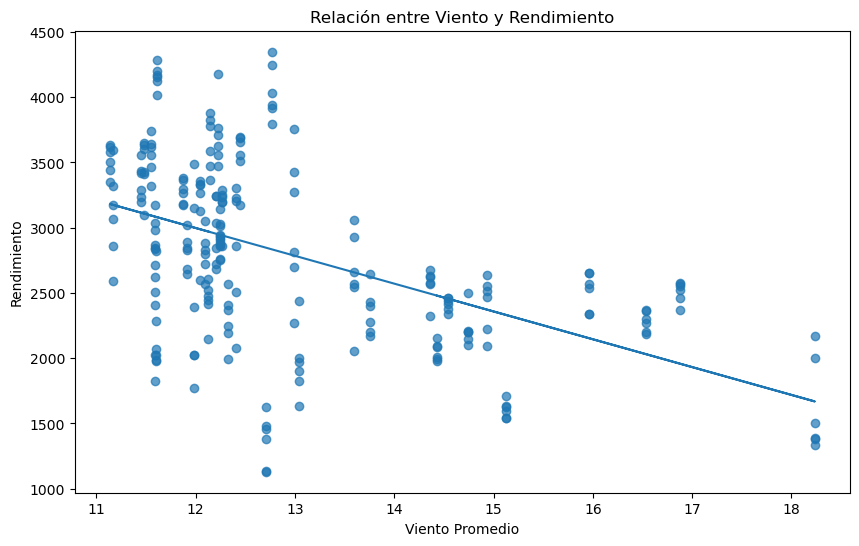

In [43]:
plt.figure(figsize=(10,6))

plt.scatter(
    dataset["viento_prom"],
    dataset["Rendimiento"],
    alpha=0.7
)

z = np.polyfit(
    dataset["viento_prom"],
    dataset["Rendimiento"],
    1
)

p = np.poly1d(z)

plt.plot(
    dataset["viento_prom"],
    p(dataset["viento_prom"])
)

plt.xlabel("Viento Promedio")

plt.ylabel("Rendimiento")

plt.title("Relación entre Viento y Rendimiento")

plt.show()

# Análisis Visual de Relaciones Agroclimáticas

## Relación entre precipitación y rendimiento

Se realizó un análisis visual mediante gráficos de dispersión para evaluar la relación entre variables climáticas y el rendimiento de soja.

El gráfico de precipitación total versus rendimiento mostró una tendencia positiva general, indicando que mayores niveles de precipitación tienden a asociarse con mayores rendimientos agrícolas.

Sin embargo, la relación observada no es completamente lineal. Se identificó una dispersión considerable entre campañas con niveles similares de precipitación, lo que sugiere la presencia de:

* interacciones complejas entre variables climáticas,
* efectos no lineales,
* posibles umbrales climáticos,
* y factores adicionales no representados únicamente por la precipitación acumulada.

También se observaron campañas extremadamente húmedas con rendimientos relativamente moderados, lo cual podría estar asociado a fenómenos de exceso hídrico o anegamiento.

Estos resultados ayudan a explicar por qué el modelo Random Forest presentó una capacidad predictiva considerablemente superior al modelo lineal OLS.

---

# Relación entre viento y rendimiento

El gráfico de dispersión entre viento promedio y rendimiento mostró una relación negativa clara y consistente.

A medida que aumenta el viento promedio, los rendimientos tienden a disminuir.

Además, las campañas con mayores rendimientos aparecen concentradas principalmente en valores bajos o moderados de viento.

Este comportamiento refuerza los resultados obtenidos previamente mediante:

* correlación lineal,
* análisis OLS,
* e importancia de variables en Random Forest.

Desde el punto de vista agroclimático, el viento podría estar asociado a:

* mayor evapotranspiración,
* incremento del estrés hídrico,
* pérdida de humedad disponible,
* y mayor demanda atmosférica sobre el cultivo.

La consistencia observada entre múltiples métodos estadísticos y de machine learning fortalece la hipótesis de que el componente hídrico constituye uno de los principales determinantes del rendimiento agrícola dentro del dataset analizado.

---

# Interpretación general

Los análisis visuales permitieron confirmar que:

* la precipitación presenta una relación positiva con el rendimiento,
* el viento presenta una relación negativa importante,
* las relaciones agroclimáticas no son completamente lineales,
* y los modelos no lineales como Random Forest son especialmente útiles para capturar patrones complejos presentes en sistemas agroclimáticos reales.


In [44]:
escenario_base = X.mean().to_frame().T

escenario_base

,score_suelo_promedio,temp_max_extrema,temp_min_extrema,precipitacion_total,viento_prom,dias_lluvia
0,2.699202,37.79025,-4.74975,996.1879,13.007171,90.775


In [45]:
rendimiento_base = modelo_rf.predict(escenario_base)[0]

print("Rendimiento base estimado:", round(rendimiento_base, 2))

Rendimiento base estimado: 2820.36


In [46]:
escenarios = escenario_base.copy()

escenarios = pd.concat(
    [
        escenario_base,
        escenario_base.copy(),
        escenario_base.copy(),
        escenario_base.copy()
    ],
    ignore_index=True
)

escenarios.index = [
    "Base",
    "Sequía moderada",
    "Mayor estrés térmico",
    "Viento alto"
]

In [47]:
escenarios.loc["Sequía moderada", "precipitacion_total"] *= 0.85
escenarios.loc["Sequía moderada", "dias_lluvia"] *= 0.85

escenarios.loc["Mayor estrés térmico", "temp_max_extrema"] += 2
escenarios.loc["Mayor estrés térmico", "temp_min_extrema"] += 1

escenarios.loc["Viento alto", "viento_prom"] *= 1.15

escenarios

,score_suelo_promedio,temp_max_extrema,temp_min_extrema,precipitacion_total,viento_prom,dias_lluvia
Base,2.699202,37.79025,-4.74975,996.187900,13.007171,90.77500
Sequía moderada,2.699202,37.79025,-4.74975,846.759715,13.007171,77.15875
Mayor estrés térmico,2.699202,39.79025,-3.74975,996.187900,13.007171,90.77500
Viento alto,2.699202,37.79025,-4.74975,996.187900,14.958246,90.77500


In [48]:
predicciones = modelo_rf.predict(escenarios)

resultado_escenarios = pd.DataFrame({
    "Escenario": escenarios.index,
    "Rendimiento_estimado": predicciones
})

resultado_escenarios["Cambio_vs_base"] = (
    resultado_escenarios["Rendimiento_estimado"] - rendimiento_base
)

resultado_escenarios["Cambio_%"] = (
    resultado_escenarios["Cambio_vs_base"] / rendimiento_base * 100
)

resultado_escenarios

,Escenario,Rendimiento_estimado,Cambio_vs_base,Cambio_%
0,Base,2820.363333,0.000000,0.000000
1,Sequía moderada,2852.963333,32.600000,1.155879
2,Mayor estrés térmico,2724.783333,-95.580000,-3.388925
3,Viento alto,2495.306667,-325.056667,-11.525347


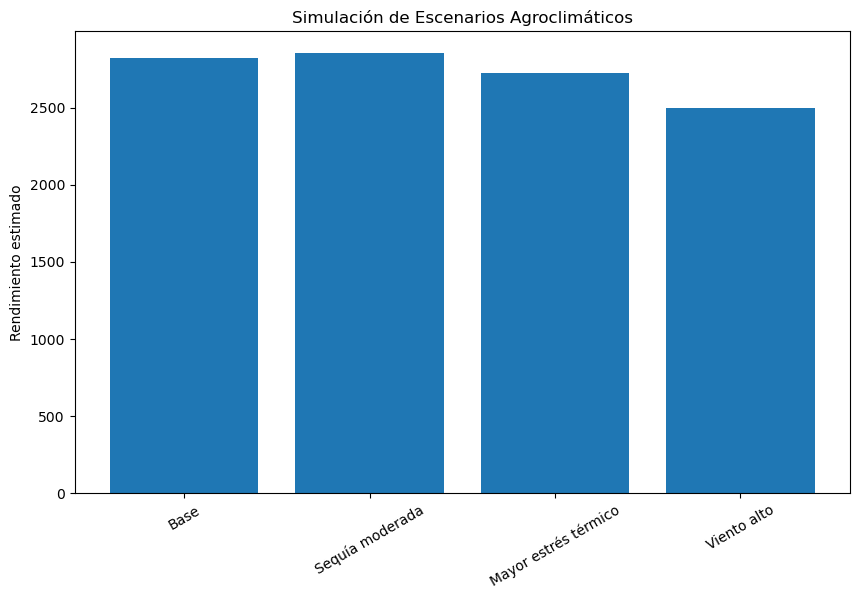

In [49]:
plt.figure(figsize=(10,6))

plt.bar(
    resultado_escenarios["Escenario"],
    resultado_escenarios["Rendimiento_estimado"]
)

plt.title("Simulación de Escenarios Agroclimáticos")

plt.ylabel("Rendimiento estimado")

plt.xticks(rotation=30)

plt.show()

# Simulación de Escenarios Agroclimáticos

## Construcción de escenarios climáticos

Se implementó una simulación de escenarios agroclimáticos utilizando el modelo Random Forest previamente entrenado.

El objetivo fue evaluar cómo diferentes modificaciones en las condiciones climáticas podrían afectar el rendimiento estimado de soja.

Para ello se construyó inicialmente un escenario base utilizando los valores promedio históricos de las variables agroclimáticas analizadas.

Posteriormente se generaron distintos escenarios modificando variables específicas:

* reducción moderada de precipitación,
* incremento del estrés térmico,
* y aumento de velocidad del viento.

---

# Escenario base

El escenario promedio histórico presentó un rendimiento estimado aproximado de:

* 2820 kg/ha

Este valor fue utilizado como referencia para comparar el efecto de los distintos cambios climáticos simulados.

---

# Escenario de sequía moderada

En este escenario se redujo aproximadamente un 15% la precipitación total y la cantidad de días de lluvia.

El modelo estimó un rendimiento ligeramente superior al escenario base.

Este comportamiento sugiere la posible existencia de relaciones no lineales entre precipitación y rendimiento agrícola.

Una posible interpretación es que ciertas campañas históricas podrían haber presentado exceso hídrico o anegamiento, de modo que una reducción moderada de precipitación no necesariamente implica una disminución inmediata del rendimiento.

Este resultado muestra la capacidad del modelo Random Forest para capturar interacciones complejas difíciles de representar mediante modelos lineales tradicionales.

---

# Escenario de mayor estrés térmico

En este escenario se incrementaron las temperaturas máximas y mínimas extremas.

El modelo estimó una disminución del rendimiento aproximada del:

* 3.4%

Este resultado es consistente con la evidencia observada previamente en el modelo OLS y en los análisis de correlación, donde los extremos térmicos aparecieron asociados negativamente al rendimiento agrícola.

---

# Escenario de viento alto

El escenario de aumento de velocidad del viento produjo la caída más importante del rendimiento:

* aproximadamente -11.5%

Este resultado refuerza de manera consistente todos los análisis previos realizados en el proyecto:

* correlación negativa entre viento y rendimiento,
* alta importancia de la variable viento en Random Forest,
* significancia estadística en OLS,
* y patrón visual observado en los gráficos de dispersión.

Desde una perspectiva agroclimática, este comportamiento podría estar relacionado con:

* mayor evapotranspiración,
* pérdida de humedad disponible,
* incremento del estrés hídrico,
* y aumento de la demanda atmosférica sobre el cultivo.

---

# Interpretación general

Los resultados obtenidos sugieren que:

* el componente hídrico continúa apareciendo como el principal factor explicativo del rendimiento,
* las relaciones entre variables climáticas y productividad agrícola presentan un comportamiento no lineal,
* y los modelos de machine learning permiten capturar interacciones complejas difíciles de representar mediante enfoques lineales clásicos.

La simulación de escenarios climáticos constituye una herramienta de gran utilidad para futuros análisis de impacto climático y resiliencia agrícola.


In [50]:
resultados_bt = []

In [51]:
for corte in range(180, len(X)-5):

    X_train = X.iloc[:corte]
    y_train = y.iloc[:corte]

    X_test = X.iloc[corte:corte+5]
    y_test = y.iloc[corte:corte+5]

    modelo_bt = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    modelo_bt.fit(X_train, y_train)

    pred = modelo_bt.predict(X_test)

    r2 = r2_score(y_test, pred)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    resultados_bt.append({
        "corte": corte,
        "R2": r2,
        "RMSE": rmse
    })

In [52]:
bt_df = pd.DataFrame(resultados_bt)

bt_df.head()

,corte,R2,RMSE
0,180,0.687511,312.770626
1,181,0.629664,356.264886
2,182,0.644910,358.099522
3,183,0.686333,330.292822
4,184,0.471815,375.176513


In [53]:
print("R² promedio:",
      round(bt_df["R2"].mean(), 3))

print("RMSE promedio:",
      round(bt_df["RMSE"].mean(), 2))

R² promedio: 0.523
RMSE promedio: 247.79


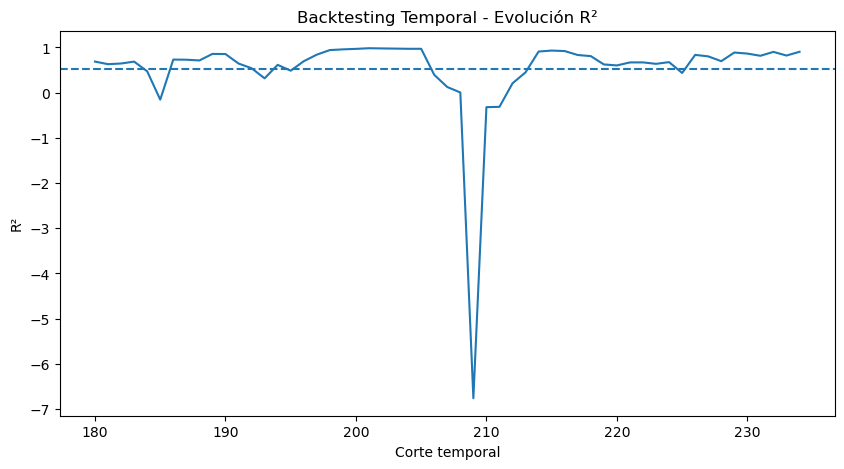

In [54]:
plt.figure(figsize=(10,5))

plt.plot(
    bt_df["corte"],
    bt_df["R2"]
)

plt.axhline(
    bt_df["R2"].mean(),
    linestyle="--"
)

plt.title("Backtesting Temporal - Evolución R²")

plt.xlabel("Corte temporal")

plt.ylabel("R²")

plt.show()

In [55]:
dataset.iloc[205:215][
    [
        "Campaña",
        "Rendimiento",
        "precipitacion_total",
        "viento_prom",
        "temp_max_extrema",
        "dias_lluvia"
    ]
]

,Campaña,Rendimiento,precipitacion_total,viento_prom,temp_max_extrema,dias_lluvia
205,1988/89,1545,464.058,15.122918,38.50,50
206,1989/90,2368,971.804,16.539917,38.00,78
207,1990/91,2565,1987.550,16.877989,35.11,91
208,1991/92,2653,1013.460,15.965525,35.50,94
209,1992/93,2550,980.440,14.929973,35.28,94
210,1993/94,2401,918.718,13.751753,37.00,80
211,1994/95,2521,855.472,12.128022,36.50,65
212,1995/96,2244,724.662,12.323781,39.61,64
213,1996/97,2435,629.920,13.036986,37.00,83
214,1997/98,3015,1035.050,12.245801,35.11,110


# Conclusiones Generales del Modelado Agroclimático

## Resultados generales

A lo largo del presente análisis se desarrolló un flujo completo de modelado agroclimático utilizando información climática histórica, variables de suelo y datos de rendimiento de soja.

El trabajo incluyó:

* auditoría y limpieza de datos NOAA,
* integración de datasets climáticos y agrícolas,
* análisis estadístico mediante modelos OLS,
* implementación de modelos de machine learning,
* análisis visual de relaciones agroclimáticas,
* validación temporal,
* y simulación de escenarios climáticos.

Los resultados obtenidos muestran que las variables climáticas poseen una influencia significativa sobre el rendimiento agrícola.

---

# Principales hallazgos

## Dominancia del componente hídrico

Los análisis realizados indican que el componente hídrico aparece como el principal determinante del rendimiento de soja dentro del dataset analizado.

Las variables más relevantes fueron:

* precipitación total,
* frecuencia de días de lluvia,
* y viento promedio.

El viento mostró una relación negativa particularmente fuerte con el rendimiento, apareciendo de forma consistente en:

* correlaciones,
* modelos OLS,
* Random Forest,
* análisis visuales,
* y simulaciones climáticas.

Esto sugiere una posible relación con procesos de evapotranspiración y estrés hídrico atmosférico.

---

# Modelos lineales y no lineales

El modelo OLS permitió interpretar estadísticamente las relaciones entre variables climáticas y rendimiento agrícola.

Sin embargo, el modelo Random Forest mostró una capacidad predictiva considerablemente superior, evidenciando la existencia de relaciones no lineales e interacciones complejas entre variables agroclimáticas.

Los resultados obtenidos mediante Random Forest sugieren que los sistemas agrícolas reales presentan dinámicas difíciles de representar completamente mediante modelos lineales tradicionales.

---

# Validación temporal y campañas extremas

El análisis de backtesting temporal mostró que el modelo presenta un comportamiento generalmente estable, aunque con dificultades importantes frente a campañas climáticamente extremas.

Se identificaron campañas con:

* sequías severas,
* precipitaciones extremadamente elevadas,
* y fuertes cambios en variables atmosféricas.

Estos resultados muestran la sensibilidad del sistema agrícola frente a eventos climáticos extremos y destacan la importancia de incorporar nuevas variables climáticas para mejorar la robustez del modelo.

---

# Limitaciones actuales

Entre las principales limitaciones identificadas se encuentran:

* ausencia de variables atmosféricas adicionales,
* falta de información fenológica detallada,
* simplificación del índice de suelo,
* y posible influencia de factores agronómicos no incluidos en el modelo.

Asimismo, el comportamiento observado en campañas extremas sugiere que algunas relaciones climáticas podrían no estar completamente representadas mediante las variables actuales.

---

# Próximas etapas del proyecto

Como continuación del proyecto se propone incorporar nuevas variables agroclimáticas avanzadas, especialmente:

* humedad relativa,
* déficit de presión de vapor (VPD),
* índices de sequía,
* ENSO,
* olas de calor,
* y variables fenológicas.

La incorporación de estas variables permitirá mejorar la capacidad explicativa y predictiva del modelo, particularmente frente a escenarios climáticos extremos.

Además, futuras etapas incluirán:

* optimización de modelos,
* validaciones avanzadas,
* nuevos algoritmos de machine learning,
* y simulaciones agroclimáticas más complejas.

---

# Conclusión final

Los resultados obtenidos muestran que el enfoque agroclimático implementado constituye una base sólida para el desarrollo de modelos predictivos agrícolas utilizando técnicas de ciencia de datos y machine learning.

El proyecto permitió identificar relaciones climáticas relevantes, construir modelos predictivos robustos y generar herramientas iniciales de simulación climática aplicadas al rendimiento agrícola.
